In [1]:
import jax.numpy as jnp
import jax.tree_util as jtu
from jax import nn, vmap, lax, jit
from jax import random as jr
import numpy as np

from pymdp.envs import GridWorldEnv
from pymdp.jax.task import PyMDPEnv
from pymdp.jax.agent import Agent as AIFAgent

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
START = 0
CC = 1
CD = 2
DC = 3
DD = 4

C = 0
D = 1
ALL_STATES = [START, CC, CD, DC, DD]
ALL_STATES_LABELS = ["START", "CC", "CD", "DC", "DD"]
ALL_OBS = [START, CC, CD, DC, DD]
ALL_OBS_LABELS = ["START", "CC", "CD", "DC", "DD"]
ALL_ACTIONS = [C, D]
ALL_ACTIONS_LABELS = ["C", "D"]

In [3]:
n_batches = 1
n_turns = 100
num_latent_states = 3
num_states = len(ALL_STATES)
num_obs = len(ALL_OBS)
num_actions = len(ALL_ACTIONS)

In [4]:
def plot_A_1(A_1):
    plt.figure(figsize=(4, 4))
    sns.heatmap(A_1, annot=True, cmap='viridis', cbar=False)
    # label axes 
    ticks = [i + 0.5 for i in range(num_states)]
    plt.xticks(ticks=ticks, labels=ALL_STATES_LABELS)
    plt.yticks(ticks=ticks, labels=ALL_STATES_LABELS)
    
    
    plt.title('Transition Matrix A_1')
    plt.xlabel('Observation')
    plt.ylabel('State')
    plt.show()

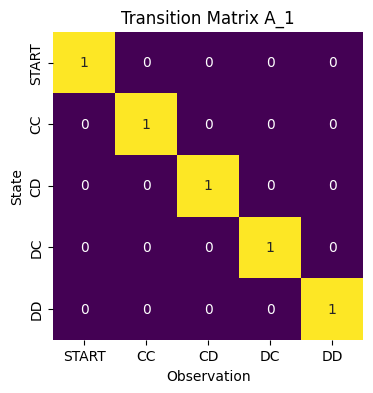

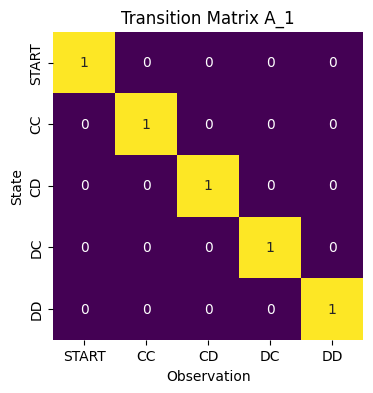

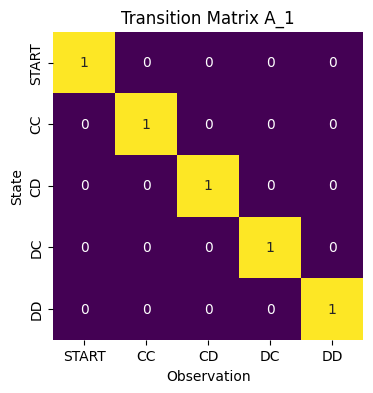

In [5]:
# Define A matrix
A_1 = np.zeros((num_obs, num_states, num_latent_states))
A_1[0, 0] = 1
A_1[1, 1] = 1
A_1[2, 2] = 1
A_1[3, 3] = 1
A_1[4, 4] = 1
plot_A_1(A_1[:, :, 0])
plot_A_1(A_1[:, :, 1])
plot_A_1(A_1[:, :, 2])

In [6]:
def plot_B_1(B_1):
    # B_1 Shape (next_state, current_state, action)
    assert B_1.shape == (num_states, num_states, num_actions), f"B_1 shape is {B_1.shape}, expected (num_states, num_states, num_actions)"
    plt.figure(figsize=(8, 4))
    for action in range(num_actions):
        plt.subplot(1, num_actions, action + 1)
        sns.heatmap(B_1[:, :, action], annot=True, cmap='viridis', cbar=False)
        # offset labels on ticks by 0.5
        ticks = [i + 0.5 for i in range(num_states)]
        plt.xticks(ticks=ticks, labels=ALL_STATES_LABELS)
        plt.yticks(ticks=ticks, labels=ALL_STATES_LABELS)
        plt.title(f'B_1 for action {ALL_ACTIONS_LABELS[action]}')
        plt.xlabel('Next State')
        plt.ylabel('Current State')
        plt.tight_layout()
    
  
    plt.show()

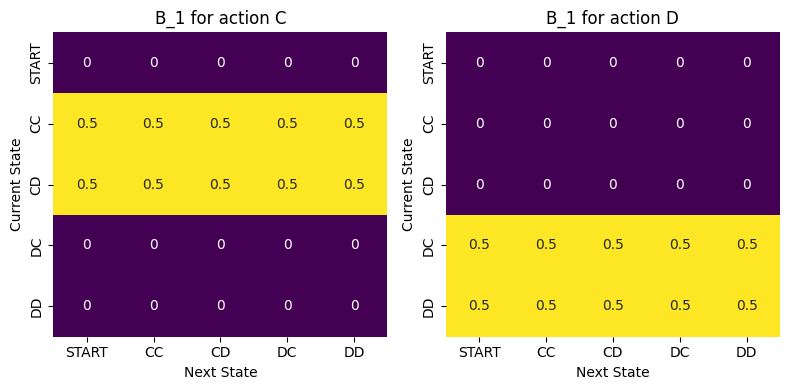

[[[1.]
  [0.]
  [0.]]

 [[0.]
  [1.]
  [0.]]

 [[0.]
  [0.]
  [1.]]]


In [7]:
B_1 = np.zeros((num_states, num_states, num_actions))
# if I cooperate in any state, The next state is CC or CD with equal probability
B_1[[CC, CD], :, 0] = 0.5
# if I defect in any state, The next state is DC or DD with equal probability
B_1[[DC, DD], :, 1] = 0.5

B_2 = np.eye(num_latent_states).reshape(num_latent_states, num_latent_states, 1)
plot_B_1(B_1)
print(B_2)

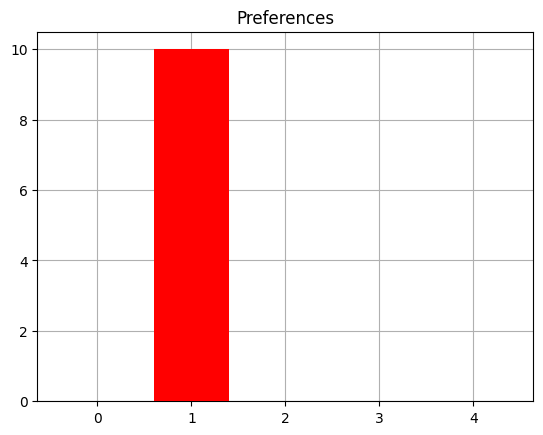

In [8]:
C_1 = np.zeros(num_obs)
C_1[CC] = 10
C_1[CD] = 0
C_1[DC] = 0
C_1[DD] = 0

def plot_C_1(C_1, title="Preferences"):
    plt.grid(zorder=0)
    plt.bar(range(C_1.shape[0]), C_1, color='r', zorder=3)
    # plt.xticks(range(C_1.shape[0]), ALL_OBS_LABELS)
    plt.title(title)
    plt.show()

plot_C_1(C_1)


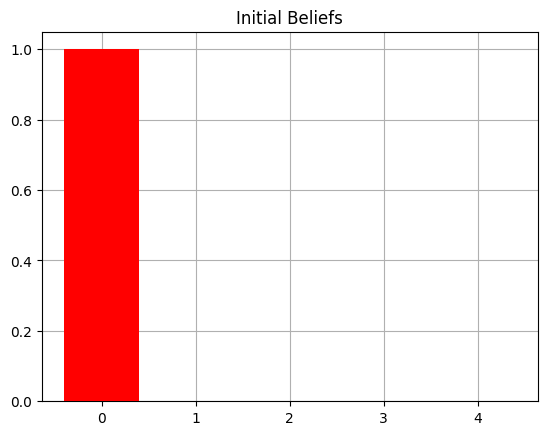

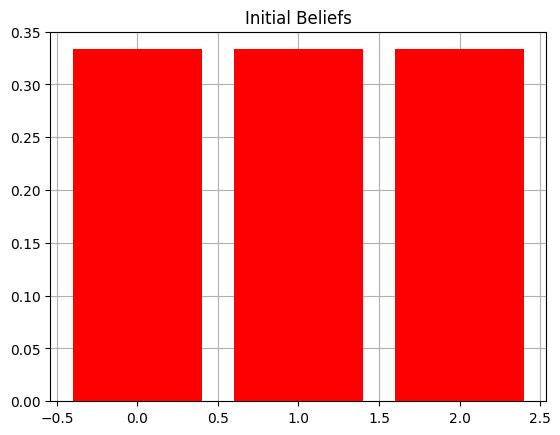

In [9]:
D_1 = np.zeros(num_states)
D_1[START] = 1

D_2 = np.ones(num_latent_states) / num_latent_states
plot_C_1(D_1, "Initial Beliefs")
plot_C_1(D_2, "Initial Beliefs")

In [10]:
FINAL_A = [jnp.broadcast_to(A_1, (n_batches,) + (num_obs, num_states, num_latent_states))]
FINAL_A[0].shape

(1, 5, 5, 3)

In [11]:
FINAL_B = [
    jnp.broadcast_to(B_1, (n_batches,) + (num_states, num_states, num_actions)),
    jnp.broadcast_to(B_2, (n_batches,) + (num_latent_states, num_latent_states, 1))
]
FINAL_B[0].shape, FINAL_B[1].shape

((1, 5, 5, 2), (1, 3, 3, 1))

In [12]:
FINAL_C = [jnp.broadcast_to(C_1, (n_batches,) + (num_obs,))]
FINAL_C[0].shape

(1, 5)

In [13]:
FINAL_D = [
    jnp.broadcast_to(D_1, (n_batches,) + (num_states,)),
    jnp.broadcast_to(D_2, (n_batches,) + (num_latent_states,))
]
FINAL_D[0].shape, FINAL_D[1].shape

((1, 5), (1, 3))

In [14]:
pB = [
    jnp.ones_like(FINAL_B[0]) / num_states,
    jnp.ones_like(FINAL_B[1]) / num_latent_states * 1000
]

agents = []
for i in range(1):
    agents.append( 
        AIFAgent(
            FINAL_A,
            FINAL_B,
            FINAL_C,
            FINAL_D,
            E=None,
            pA=None,
            pB=pB,
            policy_len=1,
            use_utility=True,
            use_states_info_gain=True,
            use_param_info_gain=True,
            gamma=jnp.ones(1),
            alpha=jnp.ones(1) * i * 0.2,
            onehot_obs=False,
            action_selection="stochastic",
            inference_algo="fpi",
            num_iter=16,
            learn_A=False,
            learn_B=True,
            learn_D=False,
        )
    )

In [15]:
agents[0].batch_size

1

In [16]:
@jit
def titfortat(obs):
    obs = obs[0][0]
    def case_START():
        return jnp.array([[C]])
    def case_CC():
        return jnp.array([[C]])
    def case_CD():
        return jnp.array([[C]])
    def case_DC():
        return jnp.array([[D]])
    def case_DD():
        return jnp.array([[D]])
    return lax.switch(obs, [case_START, case_CC, case_CD, case_DC, case_DD])


titfortat([jnp.array([[DC]])][0])

Array([[1]], dtype=int32)

In [17]:
@jit
def alwaysdefect(obs):
    return jnp.array([[D]])

alwaysdefect([jnp.array([[DC]])][0])

Array([[1]], dtype=int32)

In [18]:
@jit
def alwayscooperate(obs):
    return jnp.array([[C]])

alwayscooperate([jnp.array([[DC]])][0])

Array([[0]], dtype=int32)

In [19]:
def action_pair_to_obs(action, opponent_action):
    own_action = action[0][0]
    opponent_action = opponent_action[0][0]
    # CC -> 1 , CD -> 2, DC -> 3, DD -> 4
    # get idx from pair
    idx = 1 +(own_action * 2) + opponent_action
    return jnp.array([[idx]])

action_pair_to_obs([[C]], [[C]]), action_pair_to_obs([[C]], [[D]]), action_pair_to_obs([[D]], [[C]]), action_pair_to_obs([[D]], [[D]])

(Array([[1]], dtype=int32),
 Array([[2]], dtype=int32),
 Array([[3]], dtype=int32),
 Array([[4]], dtype=int32))

In [20]:
import jax 

def rollout(rng, agent, strategy, n_turns):
    batch_size = agent.batch_size

    def step_fn(carry, t):
        print(t)
        print(carry)
        obs_t = carry["obs"]
        rng_key = carry["rng_key"]
        empirical_prior_t = carry["empirical_prior"]

        qs = agent.infer_states(obs_t, empirical_prior_t)
        print(qs)
        qpi, _ = agent.infer_policies(qs)
        print(qpi)

        rng_key = jr.split(rng_key)
        action = agent.sample_action(qpi, rng_key=rng_key[1:])

        opponent_action = strategy(obs_t[0])
        print(action)
        print(opponent_action)

        next_obs = [action_pair_to_obs(action, opponent_action)]
        print(next_obs)

        empirical_prior_t, qs = agent.update_empirical_prior(action, qs)

        carry = {
            "obs": next_obs,
            "rng_key": rng_key[0],
            "empirical_prior": empirical_prior_t,
        }

        info = {
            "obs": obs_t,
            "qs": qs,
            "qpi": qpi,
            "action": action,
            "empirical_prior": empirical_prior_t,
        }
        return carry, info
    
    keys = jr.split(rng, batch_size)
    
    obs_t0 = [jnp.broadcast_to(jnp.array([START]), (batch_size,1))]

    carry = {
        "obs": obs_t0,
        "rng_key": keys[0],
        "empirical_prior": agent.D,
    }

    last_carry, infos = lax.scan(step_fn, carry, jnp.arange(n_turns))

    return last_carry, infos

with jax.disable_jit():
    carry, infos = rollout(jr.PRNGKey(0), agents[0], titfortat, 2)

0
{'obs': [Array([[0]], dtype=int32)], 'rng_key': Array([1797259609, 2579123966], dtype=uint32), 'empirical_prior': [Array([[1., 0., 0., 0., 0.]], dtype=float32), Array([[0.33333334, 0.33333334, 0.33333334]], dtype=float32)]}
[Array([[[1.000000e+00, 4.930398e-32, 4.930398e-32, 4.930398e-32,
         4.930398e-32]]], dtype=float32), Array([[[0.33333334, 0.33333334, 0.33333334]]], dtype=float32)]
[[0.9933072  0.00669286]]
[[1 0]]
[[0]]
[Array([[3]], dtype=int32)]
1
{'obs': [Array([[3]], dtype=int32)], 'rng_key': Array([4165894930,  804218099], dtype=uint32), 'empirical_prior': [Array([[0. , 0. , 0. , 0.5, 0.5]], dtype=float32), Array([[0.33333334, 0.33333334, 0.33333334]], dtype=float32)]}
[Array([[[9.860782e-32, 9.860782e-32, 9.860782e-32, 1.000000e+00,
         2.220450e-16]]], dtype=float32), Array([[[0.33333334, 0.33333334, 0.33333334]]], dtype=float32)]
[[0.9933072  0.00669286]]
[[1 0]]
[[1]]
[Array([[4]], dtype=int32)]


In [21]:
infos["qs"][1]

Array([[[[0.33333334, 0.33333334, 0.33333334]]],


       [[[0.33333334, 0.33333334, 0.33333334]]]], dtype=float32)

In [ ]:

Bs = []
obs = []
num_timesteps = 500
num_blocks = 1000

key = jr.PRNGKey(0)
for block in range(num_blocks):
    for i, agent in enumerate(agents):
        key, _key = jr.split(key)

        options = [alwaysdefect, alwayscooperate, titfortat]
        strategy = jax.tree_util.Partial(options[np.random.randint(0, len(options))])
        last, info = jit(rollout, static_argnums=[3,] )(_key, agent, strategy, num_timesteps)

        beliefs = info['qs']
        print(beliefs[0].shape)
        beliefs = [
            jnp.reshape(beliefs[0], (n_batches, num_timesteps, num_states)),
            jnp.reshape(beliefs[1], (n_batches, num_timesteps, num_latent_states))
        ]
        print(beliefs[0].shape)
        print(beliefs[0][0].shape)
        print(beliefs[1].shape)
        print(beliefs[1][0].shape)
        print("_"*100)
        
        actions = info['action']
        print(actions.shape)
        actions = [jnp.reshape(actions, (n_batches, num_timesteps, 2))[:, :-1, :]]
        print(actions[0].shape)
        print(actions[0][0][0][0])
        print("_"*100)

        outcomes = info['obs']
        print(outcomes[0].shape)
        outcomes = [jnp.reshape(outcomes[0], (n_batches, num_timesteps))]
        print(outcomes[0].shape)
        print(outcomes[0][0][0])
        obs.append(outcomes[0])
        print("_"*100)

        agents[i] = agent.infer_parameters(beliefs, outcomes[0], actions[0])
        Bs.append(agents[i].B)

JitTracer<int32[]>
{'empirical_prior': [JitTracer<float32[1,5]>, JitTracer<float32[1,3]>], 'obs': [JitTracer<int32[1,1]>], 'rng_key': JitTracer<uint32[2]>}
[JitTracer<float32[1,1,5]>, JitTracer<float32[1,1,3]>]
JitTracer<float32[1,2]>
JitTracer<int32[1,2]>
JitTracer<int32[1,1]>
[JitTracer<int32[1,1]>]
(500, 1, 1, 5)
(1, 500, 5)
(500, 5)
(1, 500, 3)
(500, 3)
____________________________________________________________________________________________________
(500, 1, 2)
(1, 499, 2)
0
____________________________________________________________________________________________________
(500, 1, 1)
(1, 500)
0
____________________________________________________________________________________________________
JitTracer<int32[]>
{'empirical_prior': [JitTracer<float32[1,5]>, JitTracer<float32[1,3]>], 'obs': [JitTracer<int32[1,1]>], 'rng_key': JitTracer<uint32[2]>}
[JitTracer<float32[1,1,5]>, JitTracer<float32[1,1,3]>]
JitTracer<float32[1,2]>
JitTracer<int32[1,2]>
JitTracer<int32[1,1]>
[JitTrace

In [ ]:
for B in Bs[-5:]:
    plot_B_1(B[0].reshape(num_states, num_states, num_actions))
    print(B[1][0, :, :, 0])


In [ ]:
obs[0]

def count_obs(obs):
    for o in obs:
        CC_count = 0
        CD_count = 0
        DC_count = 0
        DD_count = 0
        for i in o[0]:
            if i == 1:
                CC_count += 1
            elif i == 2:
                CD_count += 1
            elif i == 3:
                DC_count += 1
            elif i == 4:
                DD_count += 1
        print(CC_count, CD_count, DC_count, DD_count)

count_obs(obs)

In [ ]:
agents[0].A

In [ ]:
agents[0].C

In [ ]:
agents[0].D

In [ ]:
agent = AIFAgent(
    A = agents[0].A,
    B = agents[0].B,
    C = agents[0].C,
    D = agents[0].D,
    pA = agents[0].pA,
    pB = agents[0].pB,
    E = None,
    policy_len=10,
    use_utility=True,
    use_states_info_gain=False,
    use_param_info_gain=False,
    gamma=jnp.ones(1),
    alpha=jnp.ones(1),
    onehot_obs=False,
    action_selection="deterministic",
    inference_algo="vmp",
)

In [ ]:
def run_new_agent(agent, num_timesteps):
    rng = jr.PRNGKey(0)
    strategy = jax.tree_util.Partial(alwaysdefect)
    last, infos = jit(rollout, static_argnums=[3,])(rng, agent, strategy, num_timesteps)
    for obs in infos['obs']:
        for o in obs:
            if o[0][0] == 1:
                print("CC")
            elif o[0][0] == 2:
                print("CD")
            elif o[0][0] == 3:
                print("DC")
            elif o[0][0] == 4:
                print("DD")
                
run_new_agent(agent, 500)
